# Getting the most out of GPT-5.4 for document and multimodal understanding

GPT-5.4 marks a meaningful leap forward for real-world multimodal workloads, with notably stronger reliability on dense, document-centric tasks such as scans, forms, charts, and technical diagrams.

Documents that previously strained vision systems or required stitching together OCR, layout detection, and custom parsers, including dense scans, handwritten forms, engineering diagrams, and chart-heavy reports, can now often be interpreted and reasoned over in a single model pass with GPT-5.4.

However, model configuration is key for unlocking SOTA results. Small choices around image detail, verbosity, reasoning effort, and tool usage can significantly affect performance. 

This notebook focuses on the highest-leverage adjustments for document workloads: image detail, verbosity, reasoning effort, and tool use. The goal is to show when each one matters, how it changes the output, and how to choose a setup that is both robust and practical.

## A quick decision guide
Use this as a starting point. A good rule of thumb is to start simple, then adjust the setting that matches the failure mode. 

| If your task looks like this | Start with this setup | Why |
|---|---|---|
| Ordinary document QA or extraction | `detail="auto"` | Lowest-friction default for readable pages |
| Dense scans, screenshots, handwriting, or tiny labels | `detail="original"` | Preserves small visual signals that often get lost |
| Literal transcription or markdown conversion | `text={"verbosity": "high"}` | Encourages the model to keep more layout and fewer paraphrases |
| Region localization | Ask for `[x_min, y_min, x_max, y_max]` in a fixed `0..999` grid | Easy to crop, draw, debug, and feed into downstream systems |
| Chart, table, form, or drawing QA across multiple regions | increase reasoning effort to 'high' or 'xhigh' | Improves multi-step visual reasoning |
| Multi-pass visual inspection | Add Code Interpreter | Best when a human would zoom, crop, rotate, or inspect several subregions before answering |

## Setup

Run this notebook from the `openai-cookbook/examples/multimodal` directory so the relative image paths resolve correctly.

If needed, install the notebook dependencies first:

```bash
pip install --upgrade openai pillow
```

Ground-truth checks for the structured examples live in `document_and_multimodal_understanding_tips_checks.py` so the notebook can stay focused on the visual demos.


In [42]:
import base64
import io
import json
import mimetypes
import re
import tempfile
from pathlib import Path

from IPython.display import HTML, Markdown, display
from PIL import Image, ImageDraw
from openai import OpenAI

client = OpenAI()


### Shared helpers

The next cell keeps the repeated setup in one place: request construction, JSON rendering, box visualization, and crop generation.


In [43]:
def image_to_data_url(image_path: str | Path) -> str:
    path = Path(image_path)
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    mime_type = mimetypes.guess_type(path.name)[0] or "image/png"
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:{mime_type};base64,{encoded}"



def extract_json(text: str):
    cleaned = text.strip()
    if cleaned.startswith("```"):
        cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned)
        cleaned = re.sub(r"\s*```$", "", cleaned)

    candidates = [cleaned]
    for opening, closing in [("{", "}"), ("[", "]")]:
        start = cleaned.find(opening)
        end = cleaned.rfind(closing)
        if start != -1 and end != -1 and end > start:
            candidates.insert(0, cleaned[start : end + 1])

    for candidate in candidates:
        try:
            return json.loads(candidate)
        except json.JSONDecodeError:
            continue

    raise ValueError("Response did not contain valid JSON.")



def show_text(title: str, text: str) -> None:
    display(Markdown(f"### {title}\n\n```text\n{text}\n```"))



def show_json(title: str, payload) -> None:
    display(Markdown(f"### {title}\n\n```json\n{json.dumps(payload, indent=2, ensure_ascii=False)}\n```"))



def show_image(image_path: str | Path, width: int = 720, alt: str = "") -> None:
    path = Path(image_path).as_posix()
    display(HTML(f'<img src="{path}" alt="{alt}" style="max-width: 100%; width: {width}px;" />'))



def show_pil_image(image: Image.Image, width: int = 720, alt: str = "") -> None:
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
    display(HTML(f'<img src="data:image/png;base64,{encoded}" alt="{alt}" style="max-width: 100%; width: {width}px;" />'))



def run_vision(
    prompt: str,
    image_path: str | Path,
    *,
    model: str = "gpt-5.4",
    detail: str = "auto",
    reasoning_effort: str | None = None,
    verbosity: str | None = None,
    instructions: str | None = None,
    tools: list[dict] | None = None,
    include: list[str] | None = None,
):
    request = {
        "model": model,
        "input": [
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": prompt},
                    {
                        "type": "input_image",
                        "image_url": image_to_data_url(image_path),
                        "detail": detail,
                    },
                ],
            }
        ],
    }
    if reasoning_effort:
        request["reasoning"] = {"effort": reasoning_effort}
    if verbosity:
        request["text"] = {"verbosity": verbosity}
    if instructions:
        request["instructions"] = instructions
    if tools:
        request["tools"] = tools
    if include:
        request["include"] = include
    return client.responses.create(**request)



def run_and_show_text(title: str, prompt: str, image_path: str | Path, **kwargs):
    response = run_vision(prompt, image_path, **kwargs)
    show_text(title, response.output_text)
    return response



def run_and_show_json(title: str, prompt: str, image_path: str | Path, **kwargs):
    response = run_vision(prompt, image_path, **kwargs)
    payload = extract_json(response.output_text)
    show_json(title, payload)
    return payload



def denormalize_bbox(bbox: list[int], width: int, height: int) -> list[int]:
    x_min, y_min, x_max, y_max = bbox
    return [
        round(x_min * (width - 1) / 999),
        round(y_min * (height - 1) / 999),
        round(x_max * (width - 1) / 999),
        round(y_max * (height - 1) / 999),
    ]



def annotate_bboxes(image_path: str | Path, detections: list[dict]) -> Image.Image:
    annotated = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(annotated)
    width, height = annotated.size
    palette = ["red", "dodgerblue", "limegreen", "orange", "magenta", "cyan"]

    for index, item in enumerate(detections):
        color = palette[index % len(palette)]
        pixel_bbox = denormalize_bbox(item["bbox"], width, height)
        draw.rectangle(pixel_bbox, outline=color, width=4)
        draw.text((pixel_bbox[0] + 4, max(0, pixel_bbox[1] - 16)), item["label"], fill=color)

    return annotated



def crop_region(image_path: str | Path, bbox: list[int], padding: float = 0.18):
    source_image = Image.open(image_path).convert("RGB")
    width, height = source_image.size
    x_min, y_min, x_max, y_max = denormalize_bbox(bbox, width, height)
    pad_x = round((x_max - x_min) * padding)
    pad_y = round((y_max - y_min) * padding)
    crop = source_image.crop(
        (
            max(0, x_min - pad_x),
            max(0, y_min - pad_y),
            min(width, x_max + pad_x),
            min(height, y_max + pad_y),
        )
    )

    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    crop_path = Path(tmp.name)
    tmp.close()
    crop.save(crop_path)
    return crop, crop_path


## 1. Increase image detail for dense pages and handwriting

The `detail` parameter controls the resolution the model uses when processing an image. Most applications should start with `detail="auto"` which lets the model choose an appropriate resolution. However, when pages contain handwriting, small labels, dense tables, low contrast scans, or screenshots with fine text, switching to `detail="original"` can significantly improve results. If the model is mostly correct but consistently misses small fields or annotations, increasing image detail is usually the first adjustment to try.

This example intentionally includes small email and phone fields, not just the larger handwritten names. Those are the kinds of details that tend to degrade first when the image is downsampled.

<img src="../../images/3C_insurance_form.png" alt="Handwritten insurance form" style="max-width: 100%; width: 720px;" />


In [44]:
handwriting_prompt = """
Read the handwritten earthquake insurance application and return JSON with these keys:
- applicant_name
- applicant_email
- applicant_home_phone
- applicant_cell_phone
- co_applicant_name
- co_applicant_email
- co_applicant_home_phone
- co_applicant_work_phone
- effective_date
- expiration_date
- dwelling_coverage_limit_usd
- square_footage
- year_of_construction
"""

handwritten_form_path = "../../images/3C_insurance_form.png"
handwriting_result = run_and_show_json(
    title="Extracted insurance form",
    prompt=handwriting_prompt,
    image_path=handwritten_form_path,
    model="gpt-5.4",
    detail="original",
)


### Extracted insurance form

```json
{
  "applicant_name": "Smith, James L",
  "applicant_email": "JSmith1@gmail.com",
  "applicant_home_phone": "510 331 5555",
  "applicant_cell_phone": "510 212 5555",
  "co_applicant_name": "Roberts, Jesse T",
  "co_applicant_email": "jrobertsjr@gmail.com",
  "co_applicant_home_phone": "510 331 5555",
  "co_applicant_work_phone": "415 626 5555",
  "effective_date": "5/31/25",
  "expiration_date": "5/31/27",
  "dwelling_coverage_limit_usd": 900000,
  "square_footage": 1200,
  "year_of_construction": 2005
}
```

## 2. Increase verbosity for faithful transcription

When asked to transcribe documents, multimodal models tend to compress layout. They preserve meaning but may simplify whitespace, line breaks, and table-like layout. This behavior is often desirable for question answering, but not for OCR-style tasks.

Increase verbosity - `text={"verbosity": "high"}` encourages the model toward a more literal rendering and precise transcription. Use it for OCR-style workloads and targeted extractions where completeness and formatting fidelity matter.

The example below  `Ticket To The Arts` panel, asking for a full transcription of all four listings while keeping the image detail fixed.

<img src="images/newspaper.png" alt="Newspaper clipping" style="max-width: 100%; width: 720px;" />


In [45]:
section_prompt = "Transcribe everything in the Ticket To The Arts section."

newspaper_path = "../../examples/multimodal/images/newspaper.png"
run_and_show_text(
    title="Transcription preview",
    prompt=section_prompt,
    image_path=newspaper_path,
    model="gpt-5.4",
    detail="high",
    verbosity="high",
)


### Transcription preview

```text
Here is a transcription of everything in the **Ticket To The Arts** section:

---

## Ticket To The Arts

### THEATER

**LYRIC STAGE BOSTON**

**CRUMBS FROM THE TABLE OF JOY**  
By Lynn Nottage  
Directed by Tasia A. Jones

Set in 1950’s Brooklyn, two sisters mourn the loss of their mother with Hollywood films, daydreams, and lots of cookies. When a shocking decision is made by their father, the family must find new meaning in what makes a home. Tickets at lyricstage.com or by calling the box office at 617-585-5678

---

### MUSIC

**Boston Chamber Music Society**

**RUSSIAN WINTER**  
Sun. 1/12 at 3PM, Sanders Theatre  
Prokofiev: Quintet in G minor, Op. 39  
Arensky: Piano Trio No. 1 in D minor, Op. 32  
Glazunov: String Quintet in A major, Op. 39  
$30-$68; Sr. +64 off; Student: $8  
617.349.0086 / bostonchambermusic.org

---

### DANCE

**MARK MORRIS DANCE GROUP**

**BACK IN BOSTON FOR THE 1ST TIME IN 6 YEARS!**

Legendary dance company Mark Morris Dance Group performs “The Look of Love”—a must-see homage to the chart-topping hits of Burt Bacharach, including “I Say a Little Prayer,” “What the World Needs Now” & more. A powerful fusion of dance and music feat. a live band and vocals sung by Broadway star Marcy Harriell, “this is choreography that, in the words of the song, says ‘more than just words could ever say’”—The New York Times  
Jan 23–26, Emerson Cutler Majestic Theatre  
For tix & info: globalartslive.org 617.876.4275

---

### MUSIC

**Symphony Pro Musica**  
Mark Churchill, Music Director

**SPM CELEBRATES THEA MUSGRAVE**

Musgraves Turbulent Landscapes, Elgar Enigma Variations, Wm. Walton Portsmouth Point. Sat Jan. 25 7:30pm Hudson High School, Sun. Jan. 26 3:00pm St. John’s Founders Hall, Shrewsbury. Tix: https://www.symphonypromusica.org

---

If you want, I can also format this as plain text only, or preserve the layout more closely.
```

Response(id='resp_0498c3d697aa501a0069a9cc404e8c819d9db6d17f0fa8902a', created_at=1772735552.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-5.4-2026-03-05', object='response', output=[ResponseOutputMessage(id='msg_0498c3d697aa501a0069a9cc41d9c4819db92c4a70846f2dbc', content=[ResponseOutputText(annotations=[], text='Here is a transcription of everything in the **Ticket To The Arts** section:\n\n---\n\n## Ticket To The Arts\n\n### THEATER\n\n**LYRIC STAGE BOSTON**\n\n**CRUMBS FROM THE TABLE OF JOY**  \nBy Lynn Nottage  \nDirected by Tasia A. Jones\n\nSet in 1950’s Brooklyn, two sisters mourn the loss of their mother with Hollywood films, daydreams, and lots of cookies. When a shocking decision is made by their father, the family must find new meaning in what makes a home. Tickets at lyricstage.com or by calling the box office at 617-585-5678\n\n---\n\n### MUSIC\n\n**Boston Chamber Music Society**\n\n**RUSSIAN WINTER**  \nSun. 1/12 at 3PM, Sanders Theat

## 3. Ask for bounding boxes in a stable format

When you need localization, do not leave the coordinate format implicit. Ask for a fixed schema like `[x_min, y_min, x_max, y_max]` and a fixed coordinate space such as `0..999` with the origin in the top-left corner.

That makes the output easy to crop, draw, debug, compare across models, and feed into downstream systems.

<img src="images/police_form.png" alt="Police report form" style="max-width: 100%; width: 720px;" />


### Detected plate regions

```json
[
  {
    "label": "vehicle_1_license_plate",
    "bbox": [
      125,
      310,
      187,
      323
    ]
  },
  {
    "label": "vehicle_2_license_plate",
    "bbox": [
      129,
      686,
      200,
      700
    ]
  }
]
```


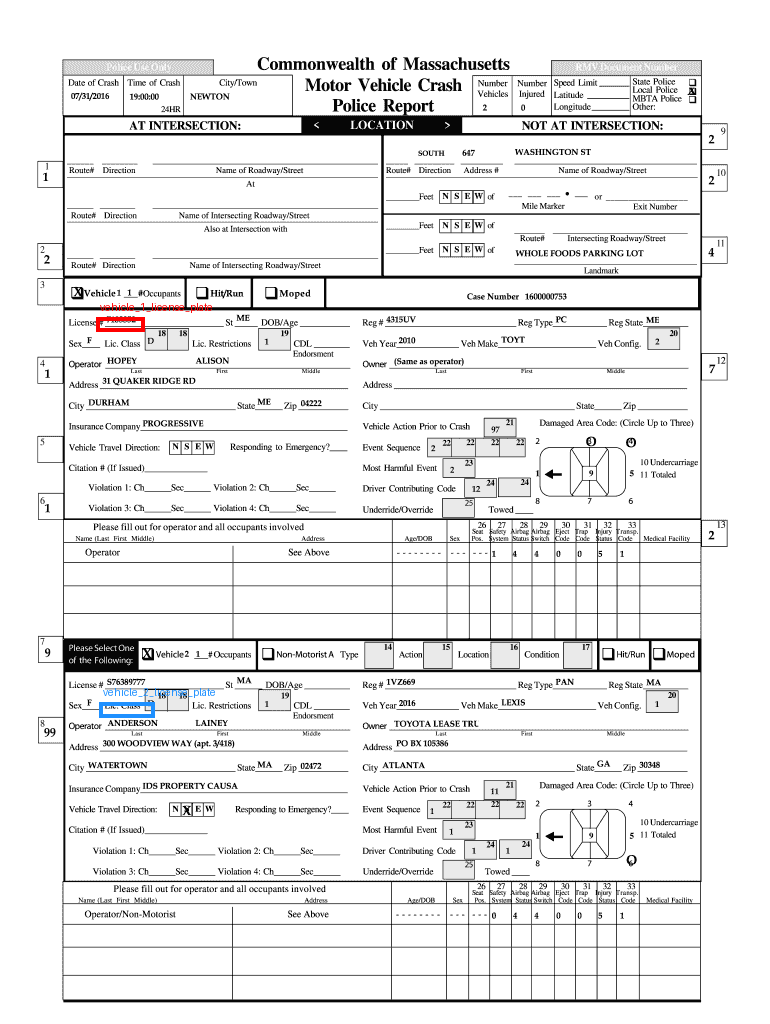

In [46]:
bbox_prompt = """
Find the license plate number for Vehicle 1 and Vehicle 2 in this police report form.
It is written after License # and is a 7-digit number.
Do not guess or infer the license plate number. 

Return JSON with this schema:
[
  {"label": "vehicle_1_license_plate", "bbox": [x_min, y_min, x_max, y_max]},
  {"label": "vehicle_2_license_plate", "bbox": [x_min, y_min, x_max, y_max]}
]

Use discrete normalized coordinates between 0 and 999.
Return JSON only.
"""

police_form_path = "../../examples/multimodal/images/police_form.png"
bbox_results = run_and_show_json(
    title="Detected plate regions",
    prompt=bbox_prompt,
    image_path=police_form_path,
    model="gpt-5.4",
    detail="original",
    reasoning_effort="high",
)

show_pil_image(annotate_bboxes(police_form_path, bbox_results), width=720, alt="Annotated plate regions")


## 4. Raise reasoning effort when the image is readable but the answer is compositional

Once the image is readable, the next bottleneck is often reasoning instead of perception. This shows up in documents where the answer depends on combining information across multiple parts of the image rather than reading a single field. Charts, tables, technical diagrams, and dense visual layouts often fall into this category.

In those cases, increasing reasoning effort can help more than increasing image detail. The model already sees the content. What it needs is more capacity to connect labels, compare regions, follow structure, and compute the final answer correctly.

Use this selectively. It is most useful when the image is legible but the task requires several visual steps before the answer becomes clear.

### Example: floorplan reasoning

The floorplan below is a good example of a task that goes beyond transcription. To answer correctly, the model has to read room labels, interpret spatial relationships, and use visible dimensions to compute values.
<img src="images/apartment_floorplan.png" alt="Apartment floorplan" style="max-width: 100%; width: 720px;" />


In [47]:
floorplan_prompt = """
Inspect this apartment floorplan and return JSON with these keys:
- total_named_rooms_excluding_hallways_and_closets
- largest_room
- room_immediately_east_of_kitchen
- room_immediately_south_of_study
- bedroom_1_total_area_ft2
- bedroom_2_total_area_ft2

Rules:
- Use the room labels and dimension annotations that are visible on the drawing.
- Return integers for numeric fields.
- Return JSON only.
"""

floorplan_path = "../../examples/multimodal/images/apartment_floorplan.png"
floorplan_result = run_and_show_json(
    title="Floorplan reasoning result",
    prompt=floorplan_prompt,
    image_path=floorplan_path,
    model="gpt-5.4",
    detail="original",
    reasoning_effort="high",
)


### Floorplan reasoning result

```json
{
  "total_named_rooms_excluding_hallways_and_closets": 7,
  "largest_room": "Living Room",
  "room_immediately_east_of_kitchen": "Dining",
  "room_immediately_south_of_study": "Bedroom 2",
  "bedroom_1_total_area_ft2": 168,
  "bedroom_2_total_area_ft2": 96
}
```

### Example: chart understanding

The same pattern shows up in chart understanding.

If the task is simply to read a title or identify one plotted value, default settings may be enough. But if the answer depends on comparing multiple series, tracking changes across adjacent intervals, or estimating trends over time, reasoning becomes the limiting factor.

That is what this example is designed to show. The model is not being asked for a single visible label. It has to compare changes across the chart and synthesize the result into structured output.

<img src="../../images/NotRealCorp_chart.png" alt="Line chart" style="max-width: 100%; width: 720px;" />


In [48]:
chart_prompt = """
Inspect this line chart and return JSON with these keys:
- largest_qoq_increase: {"channel": ..., "from_quarter": ..., "to_quarter": ..., "approx_delta_millions": ...}
- largest_qoq_drop: {"channel": ..., "from_quarter": ..., "to_quarter": ..., "approx_delta_millions": ...}
- fastest_growing_channel_overall

Rules:
- Use approximate values only when exact values are not printed.
- Base the answer on the visible lines and quarter labels.
- Return JSON only.
"""

chart_path = "../../images/NotRealCorp_chart.png"
chart_result = run_and_show_json(
    title="Chart reasoning result",
    prompt=chart_prompt,
    image_path=chart_path,
    model="gpt-5.4",
    detail="original",
    reasoning_effort="high",
)


### Chart reasoning result

```json
{
  "largest_qoq_increase": {
    "channel": "Online Sales",
    "from_quarter": "2021 Q4",
    "to_quarter": "2022 Q1",
    "approx_delta_millions": 0.15
  },
  "largest_qoq_drop": {
    "channel": "Retail Partners",
    "from_quarter": "2023 Q4",
    "to_quarter": "2024 Q1",
    "approx_delta_millions": -0.05
  },
  "fastest_growing_channel_overall": "Online Sales"
}
```

### Example: long-range visual reasoning on a dense bracket

Dense tournament brackets are a strong candidate for reasoning because the model has to follow paths across a crowded layout, keep left and right regions distinct, and identify the final outcomes without losing track of structure.

<img src="images/bracket.png" alt="Tournament bracket" style="max-width: 100%; width: 720px;" />


In [49]:
bracket_prompt = """
Inspect this tournament bracket image and return JSON with these keys:
- left_bracket_title
- right_bracket_title
- mens_champion_team
- womens_champion_team
- mens_runner_up_team
- womens_runner_up_team

Rules:
- Use the visible central championship score boxes.
- Team labels may include seeds; if you include a seed, keep it attached to the same string.
- Return JSON only.
"""

bracket_path = "../../examples/multimodal/images/bracket.png"
bracket_result = run_and_show_json(
    title="Bracket reasoning result",
    prompt=bracket_prompt,
    image_path=bracket_path,
    model="gpt-5.4",
    detail="original",
    reasoning_effort="high",
)


### Bracket reasoning result

```json
{
  "left_bracket_title": "Women’s Bracket",
  "right_bracket_title": "Men’s Bracket",
  "mens_champion_team": "Connecticut 4",
  "womens_champion_team": "L.S.U. 3",
  "mens_runner_up_team": "5 S.D. State",
  "womens_runner_up_team": "2 Iowa"
}
```

### Additional interpretation examples

These two image types fit the same pattern as charts, floorplans, and brackets: the image is readable, but the answer depends on composing several visual cues into an interpretation rather than copying text.

I would not use them as public benchmark claims without verified labels and domain review, but they are still useful as additional reasoning examples and for comparing how different models explain what they see.

<img src="images/ecg.jpg" alt="ECG" style="max-width: 100%; width: 680px;" />

<img src="images/CXR.jpeg" alt="Chest X-ray" style="max-width: 100%; width: 680px;" />


In [50]:
medical_cases = [
    {
        "title": "ECG interpretation",
        "path": "../../examples/multimodal/images/ecg.jpg",
        "prompt": (
            "A 26-year-old otherwise healthy man presents to the emergency department "
            "with a 3- to 4-hour history of left-sided chest pain. The pain is pleuritic "
            "and accompanied by nausea and discomfort in the left arm. The patient denies "
            "dyspnea, diaphoresis, fever, chills, headache, diarrhea, leg swelling, and "
            "myalgia. There is no recent history of upper respiratory tract infection, "
            "contact with ill persons, or trauma. What is the most likely dx given the EKG attached?"
        ),
    },
    {
        "title": "Chest X-ray interpretation",
        "path": "../../examples/multimodal/images/CXR.jpeg",
        "prompt": "Analyze CXR and provide the most likely diagnosis",
    },
]

for case in medical_cases:
    run_and_show_text(
        title=case["title"],
        prompt=case["prompt"],
        image_path=case["path"],
        model="gpt-5.4",
        detail="original",
        reasoning_effort="high",
        verbosity="high",
    )


### ECG interpretation

```text
The ECG is most consistent with **benign early repolarization** rather than STEMI.

Why this fits:
- **Young, healthy man** — classic population for early repolarization
- **Diffuse, concave ST elevation**, especially in the precordial leads
- **Prominent T waves / J-point elevation**
- **No clear reciprocal ST depression**
- **No obvious PR depression**, which would favor pericarditis

So the **most likely ECG diagnosis** is **benign early repolarization**.

That said, in a real ED setting, because he has acute chest pain, you would still rule out **acute pericarditis** and **ACS** with history, exam, troponins, and repeat ECGs. But from the tracing alone, **early repolarization** is the best answer.
```

### Chest X-ray interpretation

```text
The CXR most likely shows **mild hyperinflation with central/perihilar peribronchial thickening**, without focal lobar consolidation, pleural effusion, or pneumothorax.

**Most likely diagnosis:** **Reactive airways disease / asthma**  
**Alternative depending on age/clinical context:** **viral bronchiolitis**

### Key radiographic features
- Mild **hyperinflation** of the lungs
- Mild **peribronchial/interstitial prominence** centrally
- **No focal air-space opacity** to suggest pneumonia
- Cardiomediastinal silhouette is not enlarged

If you want, I can also provide this in a formal **radiology report format** with **Findings** and **Impression**.
```

## 5. Use Code Interpreter when the task benefits from multi-pass visual inspection

Some document questions are easier to answer the way a human would answer them: open the image, zoom into one region, rotate or crop a section, inspect another area, then combine the findings.

That is where Code Interpreter can help. It is useful when the task benefits from active inspection rather than a single native vision pass.

Use it when:
- the page is dense and the relevant evidence is spread across multiple regions
- you expect to zoom, crop, rotate, or inspect intermediate views
- qualitative accuracy matters more than minimum latency

The key tradeoff is that while tool use can improve difficult cases, it also introduces extra latency and execution overhead.

The cell below is opt-in because tool calls are slower and more expensive than a single native vision pass.


In [51]:
ci_prompt = """
Read the police report form and look for the travel direction and damaged area code for each vehicle.
The travel direction is written after VehicleTravel Direction.
The damaged area code is circled in black in the car diagram.
Do not guess or infer the travel direction or damaged area code.

Return JSON with these keys:
- vehicle_1_travel_direction
- vehicle_1_damaged_area_code
- vehicle_2_travel_direction
- vehicle_2_damaged_area_code

Rules:
- If the form is hard to read, inspect the relevant regions before answering.
- Return JSON only.
"""

run_code_interpreter_example = False
ci_model = "gpt-5.4"
police_form_path = "../../examples/multimodal/images/police_form.png"

if run_code_interpreter_example:
    with Path(police_form_path).open("rb") as asset_file:
        uploaded_file = client.files.create(file=asset_file, purpose="user_data")

    ci_result = run_and_show_json(
        title="Code Interpreter result",
        prompt=ci_prompt + " Use the tool at least once before answering.",
        image_path=police_form_path,
        model=ci_model,
        detail="original",
        instructions=(
            "You are an expert document analyst. Use Code Interpreter before answering. "
            "Inspect the uploaded file, crop or zoom if needed, then answer in JSON."
        ),
        tools=[
            {
                "type": "code_interpreter",
                "container": {
                    "type": "auto",
                    "memory_limit": "4g",
                    "file_ids": [uploaded_file.id],
                },
            }
        ],
        include=["code_interpreter_call.outputs"],
    )
else:
    print(
        "Skipping the Code Interpreter example. Set run_code_interpreter_example = True "
        "to run the tool-assisted version of the police-form task."
    )


Skipping the Code Interpreter example. Set run_code_interpreter_example = True to run the tool-assisted version of the police-form task.


## 6. If you cannot use Code Interpreter, build a narrow crop-and-rerun pipeline

In restricted environments, you may not want to grant the model a general Python sandbox. A practical alternative is a two-stage workflow:

1. localize the field or region you care about
2. crop that region locally
3. rerun a smaller, more focused prompt on the crop

This often recovers much of the value of multi-pass inspection while keeping the control surface small.


In [ ]:
target_region = next(
    item for item in bbox_results if item["label"] == "vehicle_2_license_plate"
)

crop, crop_path = crop_region(police_form_path, target_region["bbox"])
show_pil_image(crop, width=500, alt="Cropped license plate region")

crop_prompt = """
Read the license number value in this cropped police-form region.
It is next to the word License #.

Return JSON with one key:
- license_number

Return JSON only.
"""

crop_result = run_and_show_json(
    title="Crop-and-rerun result",
    prompt=crop_prompt,
    image_path=crop_path,
    model="gpt-5.4",
    detail="original",
)


## Guidance for Best Practices

Start with native vision when:
- the question is simple
- the page is not especially dense
- you care most about speed and cost

Add Code Interpreter when:
- the model needs multiple inspections
- the page is small, rotated, or cluttered
- you want the model to verify a reading instead of relying on one pass
- qualitative accuracy matters more than minimal token usage

Increase reasoning, even without Python, when:
- the answer depends on multiple regions of a chart, table, or form
- the task is analytical rather than pure transcription
- you can afford extra reasoning tokens for higher confidence

Expose lightweight visual tools instead of Code Interpreter when:
- you are operating in a restricted or self-hosted environment
- you want tighter control over what image transformations are allowed
- you only need crop, zoom, rotate, or an optional OCR-region fallback